## Data Wrangling
    * Identify and handle missing values
    * Data Formatting
    * Data Normalization
    * Data Binning
    * Turning Categorical to numerical variables

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
plt.style.use("dark_background")
file_path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

headers = ["symboling","normalized-losses","make","fuel-type","aspiration","num-of-doors","body-style","drive-wheels","engine-location","wheel-base","length",
           "width","height","curb-weight","engine-type","num-of-cylinders","engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
           "peak-rpm","city-mpg","highway-mpg","price"]

df = pd.read_csv(file_path, header=None, names=headers)

df.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Identify and handle missing values

### Identify missing values
#### Convert "?" to NaN
In the car data set, missing data comes with the question mark "?".
We replace "?" with NaN (Not a Number), Python's default missing value marker for reasons of computational speed and convenience. Use the function: 
    ```.replace(A, B, inplace = True) ```
to replace A by B.

In [14]:
# replace missing values

df.replace("?", np.nan, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Evaluating for Missing Data

The missing values are converted by default. Use the following functions to identify these missing values. You can use two methods to detect missing data:
<ol>
    <li><b>.isnull()</b></li>
    <li><b>.notnull()</b></li>
</ol>
The output is a boolean value indicating whether the value that is passed into the argument is in fact missing data.

In [15]:
# evaluating missing data
missing_data = df.isnull()
missing_data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
# count missing values in each column

# for each column in the missing_data dataframe, check if that column has any True value (indicating NaN)
for column in missing_data.columns.values.tolist():
    if missing_data[column].any():
        print(missing_data[column].value_counts())
        print("")


normalized-losses
False    164
True      41
Name: count, dtype: int64

num-of-doors
False    203
True       2
Name: count, dtype: int64

bore
False    201
True       4
Name: count, dtype: int64

stroke
False    201
True       4
Name: count, dtype: int64

horsepower
False    203
True       2
Name: count, dtype: int64

peak-rpm
False    203
True       2
Name: count, dtype: int64

price
False    201
True       4
Name: count, dtype: int64



In [17]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


### How to deal with missing data?
    * Check with the data collection source
    * Drop the missing values
        - drop the variable
        - drop the data entry
    * Replace the missing values
        - replace it with an average (of similar datapoints)
        - replace it by frequency
        - replace it based on other functions
    * Leave it as missing data

In [18]:
# Dealing with missing data
# 1. Drop the data by whole row or whole column
# 2. Replace data by mean value, or by frequency, or based on other functions

# Replace by mean value for "normalized-losses" column
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
df["normalized-losses"] = df["normalized-losses"].replace(np.nan, avg_norm_loss)

# Replace by mean value for "bore" column
avg_bore = df["bore"].astype("float").mean(axis=0)
df["bore"] = df["bore"].replace(np.nan, avg_bore)

# Replace by mean value for "stroke" column
avg_stroke = df["stroke"].astype("float").mean(axis=0)
df["stroke"] = df["stroke"].replace(np.nan, avg_stroke)

# Replace by mean value for "horsepower" column
avg_horsepower = df["horsepower"].astype("float").mean(axis=0)
df["horsepower"] = df["horsepower"].replace(np.nan, avg_horsepower)

# Replace by mean value for "peak-rpm" column
avg_peakrpm = df["peak-rpm"].astype("float").mean(axis=0)
df["peak-rpm"] = df["peak-rpm"].replace(np.nan, avg_peakrpm)


# Replace by frequency value for "num-of-doors" column
freq_doors = df["num-of-doors"].value_counts().idxmax() # value with highest frequency
df["num-of-doors"] = df["num-of-doors"].replace(np.nan, freq_doors)


# Drop all rows for "price" column
df.dropna(subset=["price"], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True) # re-number the index after deleting rows above


df.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [19]:
missing_data = df.isnull()
missing_data.any()  # check all columns for any nan value

symboling            False
normalized-losses    False
make                 False
fuel-type            False
aspiration           False
num-of-doors         False
body-style           False
drive-wheels         False
engine-location      False
wheel-base           False
length               False
width                False
height               False
curb-weight          False
engine-type          False
num-of-cylinders     False
engine-size          False
fuel-system          False
bore                 False
stroke               False
compression-ratio    False
horsepower           False
peak-rpm             False
city-mpg             False
highway-mpg          False
price                False
dtype: bool

### Data Formatting
    * Data is usually collected from different places and stored in different formats.
    * Bringing data into a common standard of expression allows users to make meaningful comparison. e.g. NY vs New York vs N.Y.
        - converting values from imperial to metric.
    * Incorrect data types
        - sometimes the wrong data type is assigned to a feature.

In [20]:
# Convert data types to proper format

# 1. check existing data types
df.dtypes

symboling              int64
normalized-losses     object
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

In [21]:
# 2. convert data types to proper type based on its data
df[["bore","stroke"]] = df[["bore","stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")

df.dtypes

symboling              int64
normalized-losses      int64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower            object
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

In [22]:
# Data Standardization - the process of transforming data into a common format, allowing for meaningful comparison, e.g. mpg to L/100km

# converting mpg to L/100km -  two ways of doing...
df['city-L/100km'] = 235/df['city-mpg'] # add 'city-L/100km' column based on 'city-mpg' column
df.drop(columns=['city-mpg']) # drop the 'city-mpg' column

df['highway-L/100km'] = 235/df['highway-mpg'] #recompute the 'highway-mpg' column value into L/100km value
#df.rename(columns={'highway-mpg':'highway-L/100km'}, inplace=True) # rename highway-mpg column to highway-L/100km

df.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000.0,21,27,13495.0,11.190476,8.703704
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000.0,21,27,16500.0,11.190476,8.703704
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000.0,19,26,16500.0,12.368421,9.038462
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500.0,24,30,13950.0,9.791667,7.833333
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500.0,18,22,17450.0,13.055556,10.681818


### Data Normalization
## Data Normalization

<b>Why normalization?</b>
<p>Normalization is the process of transforming values of several variables into a similar range. Typical normalizations include 
<ol>
    <li>scaling the variable so the variable average is 0</li>
    <li>scaling the variable so the variance is 1</li> 
    <li>scaling the variable so the variable values range from 0 to 1</li>
</ol>
</p>

* Methods of normalizing data
    - simple scaling; value / max value.
    - min-max; (value - min value) / (max value - min value)
    - z-score; (value - mean value) / std. deviation
    

In [23]:

df[["length","width","height"]].head()

,length,width,height
0,168.8,64.1,48.8
1,168.8,64.1,48.8
2,171.2,65.5,52.4
3,176.6,66.2,54.3
4,176.6,66.4,54.3


In [24]:
# Normalizing column "length","width","height" via scaling to values range from 0 to 1
df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()
df['height'] = df['height']/df['height'].max()

df[["length","width","height"]].head()


,length,width,height
0,0.811148,0.890278,0.816054
1,0.811148,0.890278,0.816054
2,0.822681,0.909722,0.876254
3,0.848630,0.919444,0.908027
4,0.848630,0.922222,0.908027


### Data Binning
<b>Why binning?</b>
<p>
    Binning is a process of transforming continuous numerical variables into discrete categorical 'bins' for grouped analysis.
</p>

* Grouping values into bins.
* Converts numeric into categorical variables.
* Group a set of numerical values into a set of 'bins'

In [25]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       201 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    in

In [26]:
df["horsepower"] = df["horsepower"].astype(int, copy=True)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       201 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    in

/tmp/ipykernel_7067/529958965.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df["horsepower"] = df["horsepower"].astype(int, copy=True)


Text(0.5, 1.0, 'horsepower bins')

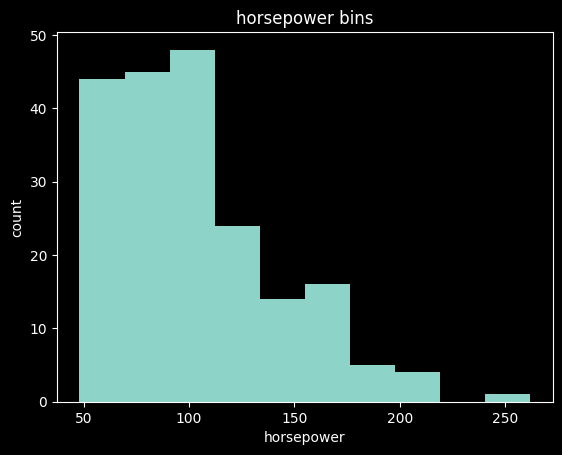

In [28]:
# plot a histogram for horsepower to see its distribution
plt.hist(df["horsepower"])

plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")


In [30]:
# binning into 3 bins
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)  # 4 = number of dividers = number of required bins + 1
bins


array([ 48.        , 119.33333333, 190.66666667, 262.        ])

In [31]:

group_names = ['Low','Medium','High'] # bin labels

df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True)
df[['horsepower','horsepower-binned']].head(20)


,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


In [32]:
# bin count for each bin category
df['horsepower-binned'].value_counts()

horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64

Text(0.5, 1.0, 'horsepower bins')

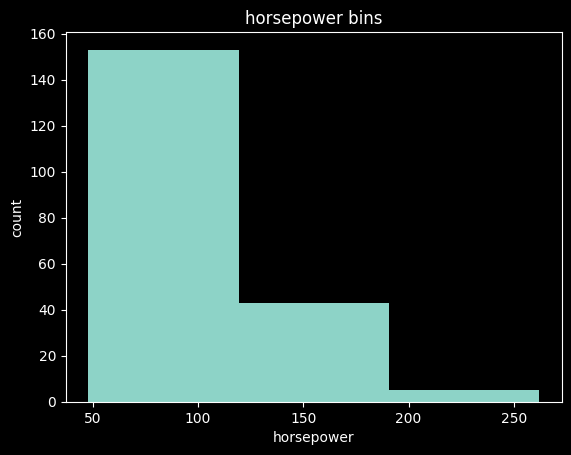

In [33]:
# Bins Visualization with histogram for the distribution of bins

plt.hist(df["horsepower"], bins=3)  # draw historgram of attribute 'horsepower' with bins=3

plt.xlabel("horsepower")
plt.ylabel("count")
plt.title("horsepower bins")

### How to Turn Categorical Variables Into Quantitative Variables
    * Most statistical models can only handle numerical values as inputs.
    * use pandas.get_dummies() to convert categorical variables to dummy variables (0 or 1)
    * e.g. pd.get_dummies(df["fuel"])
    

In [34]:
# Indicator Variable - a dummy numerical variable used to label categories for regression analysis
# e.g. 'fuel-type' column contains two unique values, 'gas' or 'diesel'
# we need to convert this to numeric value because statistic functions only can deal with numbers.
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'highway-L/100km',
       'horsepower-binned'],
      dtype='str')

In [35]:
dummy1 = pd.get_dummies(df['fuel-type']) # returns a dataframe
dummy1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
print(dummy1.head())

   fuel-type-diesel  fuel-type-gas
0             False           True
1             False           True
2             False           True
3             False           True
4             False           True


In [36]:
dummy2 = pd.get_dummies(df['aspiration']) # returns a dataframe
dummy2.rename(columns={'std':'aspiration-std', 'turbo':'aspiration-turbo'}, inplace=True)
print(dummy2.head())

   aspiration-std  aspiration-turbo
0            True             False
1            True             False
2            True             False
3            True             False
4            True             False


In [37]:
# append the above dataframes to the main dataframe along the column axis, df
df = pd.concat([df, dummy1], axis=1)
df.drop('fuel-type', axis=1, inplace=True)  # drop off the original 'fuel-type' column
df = pd.concat([df, dummy2], axis=1)
df.drop('aspiration', axis=1, inplace=True)  # drop off the original 'aspiration' column

df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,21,27,13495.0,11.190476,8.703704,Low,False,True,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,21,27,16500.0,11.190476,8.703704,Low,False,True,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,19,26,16500.0,12.368421,9.038462,Medium,False,True,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,24,30,13950.0,9.791667,7.833333,Low,False,True,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,18,22,17450.0,13.055556,10.681818,Low,False,True,True,False


In [38]:
df.to_csv('clean_df_Auto.csv')

In [39]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,0.899108,2555.666667,126.875622,3.330692,3.256874,10.164279,103.402985,5117.665368,25.179104,30.686567,13207.129353,9.944145,8.044957
std,1.254802,31.99625,6.066366,0.059213,0.029187,0.040933,517.296727,41.546834,0.268072,0.316048,4.004965,37.365650,478.113805,6.423220,6.815150,7947.066342,2.534599,1.840739
min,-2.000000,65.00000,86.600000,0.678039,0.837500,0.799331,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,4.351852
25%,0.000000,101.00000,94.500000,0.801538,0.890278,0.869565,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,6.911765
50%,1.000000,122.00000,97.000000,0.832292,0.909722,0.904682,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,7.833333
75%,2.000000,137.00000,102.400000,0.881788,0.925000,0.928094,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,9.400000
max,3.000000,256.00000,120.900000,1.000000,1.000000,1.000000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,14.687500
